# **1. Alexnet**

AlexNet은 2012년 ILSVRC(ImageNet Large Scale Visual Recognition Challenge)에서 우승한 딥러닝 모델로, 딥러닝의 대중화를 이끈 중요한 합성곱 신경망(CNN)입니다. 
<br>이 모델은 8개의 레이어(5개의 합성곱 레이어와 3개의 완전 연결 레이어)로 구성되어 있으며, 
<br>ReLU 활성화 함수, 드롭아웃(dropout), 데이터 증강(data augmentation) 등을 사용해 과적합을 방지하고 학습 성능을 향상시켰습니다. 
<br>AlexNet은 대규모 데이터셋과 GPU 병렬 연산을 활용해 1,000개의 클래스 분류 문제에서 top-1, top-5 **error rates**가 각각 37.5%, 17.5%로 뛰어난 성능을 보여, 
<br>컴퓨터 비전에서 딥러닝이 표준 기법으로 자리 잡는 데 기여했습니다. 이 성과는 당시 기준으로 매우 뛰어난 결과였습니다. 
<br>특히 AlexNet은 이전에 사용된 전통적인 머신러닝 방법론보다 훨씬 큰 차이로 성능을 끌어올리며, 딥러닝의 가능성을 보여주었습니다.

[[논문 링크](https://papers.nips.cc/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf)]


![AlexNet](./images/AlexNet.png)

### ※ ImageNet LSVRC

ImageNet LSVRC는 Large Scale Visual Recognition Challenge의 약자로, 이미지 인식 및 분류 기술을 겨루는 대회입니다. 2010년부터 매년 개최되었으며, ImageNet이라는 대규모 이미지 데이터셋을 기반으로 참가자들이 다양한 모델을 설계하고 경쟁했습니다.

- ImageNet 데이터셋: 약 1400만 장의 이미지를 포함하며, 1000개의 클래스(예: 고양이, 강아지, 자동차 등)로 분류된 대규모 이미지 데이터셋입니다.
- 목적: 컴퓨터 비전 및 딥러닝 기술의 발전을 촉진하고, 이미지 인식 분야에서 혁신적인 기술을 발견하는 것이 목표였습니다.
- LSVRC-2010: 이 대회에서 AlexNet이 2012년에 처음으로 딥러닝 기반 접근법을 사용해 뛰어난 성능을 보여줌으로써 딥러닝의 새로운 시대를 열었습니다.

### ※ Error Rate

이미지 분류 모델의 성능을 평가하는 지표로, 모델이 이미지를 얼마나 정확히 분류했는지를 나타냅니다.

 

1. Top-1 Error Rate

    - 모델이 예측한 가장 높은 확률의 클래스(Top-1)가 정답이 아닐 확률입니다.
    - 예를 들어, 이미지에 "고양이"가 있고, 모델이 가장 높은 확률로 "강아지"라고 예측했다면, 이건 Top-1 에러입니다.​

2. Top-5 Error Rate

    - 모델이 예측한 상위 5개의 클래스 중 하나라도 정답에 포함되지 않았을 확률입니다.
    - 예를 들어, 이미지가 "고양이"인데 모델이 "강아지", "토끼", "고양이", "호랑이", "여우"를 상위 5개로 예측했다면, 이건 정답으로 간주됩니다.
    - Top-5를 사용하는 이유: 사람이 보기에 유사한 클래스(예: 치타와 표범)를 분류하는 것은 어렵기 때문에, 상위 5개 중에 정답이 있는지를 확인하는 방식으로 보다 실용적인 성능을 평가합니다.

# **2. CIFAR-10**
- 32 x 32 크기의 컬러 이미지 60,000장으로 구성
- 학습용 이미지: 50,000장, 테스트용 이미지: 10,000장
- 클래스 수: 10개
- 클래스는 비행기, 자동차, 새, 고양이, 사슴, 개, 개구리, 말, 배, 트럭으로 구성

In [119]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from torch import nn
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from torchvision.transforms.functional import to_pil_image

In [120]:
SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [121]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(DEVICE)

cpu


In [122]:
DATA_DIR = Path('data')
# DATA_DIR

raw_train_dataset = datasets.CIFAR10(
    root=DATA_DIR,   # 현재 디렉터리에 다운
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

mean = raw_train_dataset.data.mean(axis=(0,1,2)) / 255.0
std = raw_train_dataset.data.std(axis=(0,1,2)) / 255.0

print('평균: ', mean)
print('표준편차: ', std)

평균:  [0.49139968 0.48215841 0.44653091]
표준편차:  [0.24703223 0.24348513 0.26158784]


###  정규화가 필요한 이유
- RGB 각 채널의 픽셀값을 평균 0 부근, 적절한 범위로 맞추면 최적화가 더 안정적으로 진행될 수 있음
- 검증 데이터와 테스트 데이터에도 학습 데이터에서 구한 평균과 표 준편차를 사용해야 함
- 검증/테스트 데이터 자체에서 통계량을 새로 계산하면 평가 데이터의 정보가 전처리에 반영되는 데이터 누수가 발생할 수 있음

In [123]:
train_transform = transforms.Compose([
    # 32 x 32 이미지를 바깥쪽으로 확장(4px)한 뒤 32 x 32로 무작위 자르기
    transforms.RandomCrop(32, padding = 4),  # 32 픽셀보다 크면 자른다
    #  50% 확률로 좌우 반전
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean = mean, std = std)
])

# 시간 오래걸려서 test 다운 안 받음
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean = mean, std = std)
])

In [124]:
train_full_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=False,
    transform=train_transform
)

validation_full_dataset = datasets.CIFAR10(
    root=DATA_DIR,   
    train=True,
    download=False,
    transform=eval_transform
)

test_dataset = datasets.CIFAR10(
    root=DATA_DIR,   
    train=True,
    download=True,
    transform=eval_transform
)

In [125]:
all_indices = np.arange(len(raw_train_dataset))
all_targets = np.array(raw_train_dataset.targets)

train_indices, validation_indices = train_test_split(
    all_indices, test_size=0.1, random_state=SEED, stratify=all_targets
)

train_dataset = Subset(train_full_dataset, train_indices)
validation_dataset = Subset(validation_full_dataset, validation_indices)

print('학습 데이터: ', len(train_dataset))
print('검증 데이터: ', len(validation_dataset))
print('테스트 데이터', len(test_dataset))

학습 데이터:  45000
검증 데이터:  5000
테스트 데이터 50000


In [126]:
BATCH_SIZE = 128
NUM_WORKERS = 0 # -1있는데로 다, 0은 추가 프로세스 만들지 않고 현재 실행 중인 프로세스가 직접 데이터를 가져옴

train_loader = DataLoader(
    train_dataset, batch_size = BATCH_SIZE, shuffle = True, num_workers = NUM_WORKERS, pin_memory = (DEVICE.type == 'cuda') # cuda일때만 True가 됨
)

validation_loader = DataLoader(
    validation_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda')
)

test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda')
)

In [127]:
class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'trunck']

In [128]:
def denormalize(image, mean, std):
    mean_tensor = torch.tensor(mean, dtype=image.dtype).view(3, 1, 1)
    std_tensor = torch.tensor(std, dtype=image.dtype).view(3, 1, 1)
    image = image.cpu() * std_tensor + mean_tensor
    return image.clamp(0, 1)

In [129]:
images, labels = next(iter(train_loader))
print('이미지 배치 모양: ', [images.shape])
print('레이블 배치 모양: ', [labels.shape])

이미지 배치 모양:  [torch.Size([128, 3, 32, 32])]
레이블 배치 모양:  [torch.Size([128])]


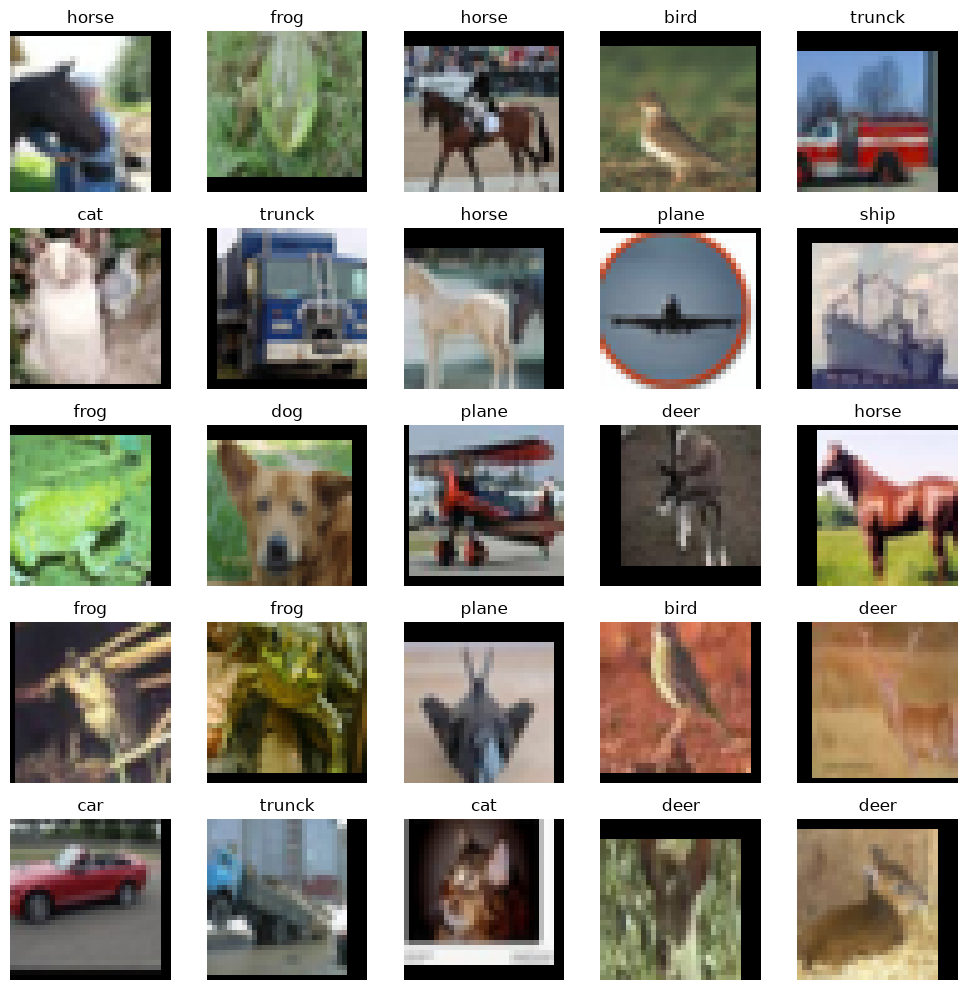

In [130]:
figure = plt.figure(figsize=(10, 10))
rows, cols = 5, 5

for index in range(rows * cols):
    image = denormalize(images[index], mean, std)

    axis = figure.add_subplot(rows, cols, index + 1)
    axis.imshow(to_pil_image(image))
    axis.set_title(class_names[labels[index].item()])
    axis.axis("off")

plt.tight_layout()
plt.show()

In [131]:
class AlexNetCIFAR10(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # 입력(128, 3, 32, 32)
            nn.Conv2d(3, 96, kernel_size=3, stride = 1, padding = 1),
            nn.ReLU(inplace = True), # 메모리 아끼려고 inplace True
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            # 출력(128, 96, 16, 16)


            nn.Conv2d(96, 256, kernel_size=3, padding = 1),
            nn.ReLU(inplace = True),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            # 출력(128, 256, 8, 8)

            nn.Conv2d(256, 384, kernel_size=3, padding = 1),
            nn.ReLU(inplace = True),

            nn.Conv2d(384, 384, kernel_size=3, padding = 1),
            nn.ReLU(inplace = True),

            nn.Conv2d(384, 256, kernel_size=3, padding = 1),
            nn.ReLU(inplace = True),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            # 출력(125, 256, 4, 4)
        )

        self.avgpool = nn.AdaptiveAvgPool2d((4,4))
        self.classifier = nn.Sequential(
            nn.Dropout(p = 0.5),
            nn.Linear(256 * 4 * 4, 1024),
            nn.ReLU(inplace=True),
            
            nn.Dropout(p = 0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace = True),
            
            nn.Linear(512, num_classes)
        )


    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, start_dim =1 )
        logits = self.classifier(x)
        return logits

In [132]:
model = AlexNetCIFAR10(num_classes=10).to(DEVICE)
model

AlexNetCIFAR10(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(96, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(4, 4))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=4096, out_features=1024, bias=Tr

In [133]:
# parameter.numel: 텐서 안에 들어있는 원소의 개수를 구하는 함수
total_parameters = sum(parameter.numel() for parameter in model.parameters())
print(f'전체 파라미터 수: {total_parameters}')

전체 파라미터 수: 8046986


In [134]:
trainable_parameters = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print(f'학습 가능한 파라미터 수: {trainable_parameters}')

학습 가능한 파라미터 수: 8046986


In [135]:
dummy_input = torch.randn(2, 3, 32, 32).to(DEVICE)

In [136]:
with torch.inference_mode():
    feature_output = model.features(dummy_input)
    pooled_output = model.avgpool(feature_output)
    logits = model(dummy_input)


In [137]:
print('합성곱 특징: ', feature_output.shape)
print('AdaptiveAvgPool: ', pooled_output.shape)
print('logit: ', logits.shape)

합성곱 특징:  torch.Size([2, 256, 4, 4])
AdaptiveAvgPool:  torch.Size([2, 256, 4, 4])
logit:  torch.Size([2, 10])


In [138]:
EPOCHS = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

### AdamW
- Adam의 편리한 최적화와 weight decay를 분리해서 적용

> AdamW가 항상 SGD보다 우수한 것은 아님. AlexNet은 momentum을 적용한 SGD를 사용했음

In [139]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr = LEARNING_RATE, weight_decay = WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = 'min', factor = 0.5, patience = 3)

# **3. 학습 함수와 평가 함수**

In [140]:
def train_one_epoch(data_loader, model, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim = 1) == labels).sum().item()
        total_samples += batch_size

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    return average_loss, accuracy

In [141]:
def evaluate(data_loader, model, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.inference_mode():
            for images, labels in data_loader:
                images = images.to(device)
                labels = labels.to(device)
                logits = model(images)
                loss = criterion(logits, labels)
                batch_size = labels.size(0)
                total_loss += loss.item() * batch_size
                total_correct += (logits.argmax(dim = 1) == labels).sum().item()
                total_samples += batch_size
    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    return average_loss, accuracy

In [142]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
BEST_MODEL_PATH = OUTPUT_DIR / "alexnet_cifar10_best.pth"
EARLY_STOPPING_PATIENCE = 5

In [143]:
history = {
    "train_loss" : [], "train_accuracy": [], "validation_loss": [], "validation_accuracy": []
}

best_validation_loss = float('inf')
epochs_without_improvment = 0

In [148]:
for epoch in range(1, EPOCHS + 1):
    train_loss, train_accuracy = train_one_epoch(train_loader, model, criterion, optimizer, DEVICE)
    validation_loss, validation_accuracy = evaluate(validation_loader, model, criterion, DEVICE)
    scheduler.step(validation_loss)
    history['train_loss'].append(train_loss)
    history['train_accuracy'].append(train_accuracy)
    history['validation_loss'].append(validation_loss)
    history['validation_accuracy'].append(validation_accuracy)
    current_lr = optimizer.param_groups[0]['lr']

    print(f'Epoch [{epoch:02d}/{EPOCHS}]'
        f'lr={current_lr:.6f} | '
        f'train loss={train_loss:.4f}, acc={train_accuracy:.4f} | '
        f'val loss={validation_loss:.4f}, acc={validation_accuracy:.4f}'
    )

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        epochs_without_improvment = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f'최고 모델 저장: {BEST_MODEL_PATH}')
    else:
        epochs_without_improvment += 1
        if epochs_without_improvment >= EARLY_STOPPING_PATIENCE:
            print('조기 종료: 검증 손실이 더 이상 개선되지 않았습니다.')
            break

    
    

Epoch [01/50]lr=0.001000 | train loss=0.6869, acc=0.7670 | val loss=0.6369, acc=0.7828
최고 모델 저장: outputs\alexnet_cifar10_best.pth
Epoch [02/50]lr=0.001000 | train loss=0.6555, acc=0.7772 | val loss=0.6381, acc=0.7788
Epoch [03/50]lr=0.001000 | train loss=0.6290, acc=0.7878 | val loss=0.6974, acc=0.7716
Epoch [04/50]lr=0.001000 | train loss=0.6144, acc=0.7922 | val loss=0.6049, acc=0.7992
최고 모델 저장: outputs\alexnet_cifar10_best.pth
Epoch [05/50]lr=0.001000 | train loss=0.5918, acc=0.7998 | val loss=0.6048, acc=0.7914
최고 모델 저장: outputs\alexnet_cifar10_best.pth
Epoch [06/50]lr=0.001000 | train loss=0.5734, acc=0.8052 | val loss=0.6194, acc=0.7958
Epoch [07/50]lr=0.001000 | train loss=0.5632, acc=0.8082 | val loss=0.5728, acc=0.8106
최고 모델 저장: outputs\alexnet_cifar10_best.pth
Epoch [08/50]lr=0.001000 | train loss=0.5460, acc=0.8154 | val loss=0.5652, acc=0.8062
최고 모델 저장: outputs\alexnet_cifar10_best.pth
Epoch [09/50]lr=0.001000 | train loss=0.5297, acc=0.8198 | val loss=0.5747, acc=0.8148
Ep

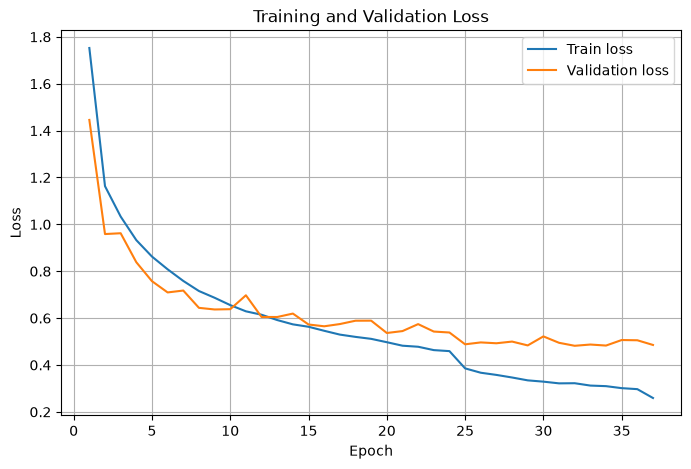

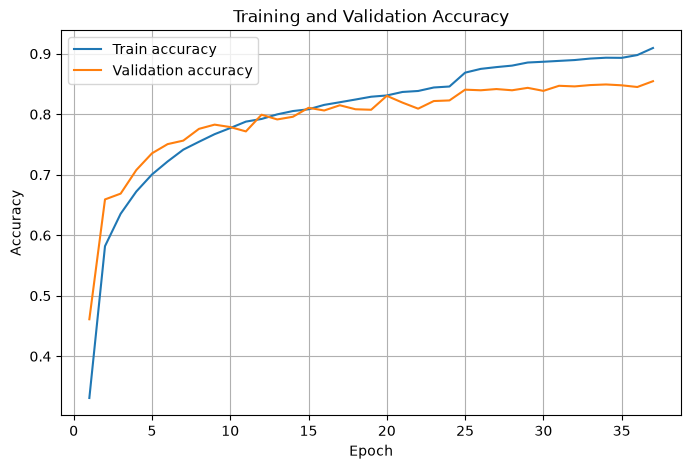

In [149]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Train loss")
plt.plot(epochs, history["validation_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_accuracy"], label="Train accuracy")
plt.plot(epochs, history["validation_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

# **4. Alexnet 모델 평가**

In [150]:
try:
    best_state_dict = torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=True)
except TypeError:
    best_state_dict = torch.load(BEST_MODEL_PATH, map_location = DEVICE)

In [151]:
model.load_state_dict(best_state_dict)

<All keys matched successfully>

In [152]:
test_loss, test_accuracy = evaluate(test_loader, model, criterion, DEVICE)
print(f'test loss: {test_loss:.4f}')
print(f'test accuracy: {test_accuracy * 100:.2f}%')

test loss: 0.2559
test accuracy: 91.25%


### 혼동행렬과 클래스별 성능

In [153]:
from sklearn.metrics import confusion_matrix, classification_report

In [154]:
def collect_predictions(data_loader, model, device):
    model.eval()
    true_labels = []
    predicted_labels = []

    with torch.inference_mode():
        for images, labels in data_loader:
            images = images.to(device)
            logits = model(images)
            predictions = logits.argmax(dim=1).cpu()
            true_labels.extend(labels.numpy().tolist())
            predicted_labels.extend(predictions.numpy().tolist())
    return np.array(true_labels), np.array(predicted_labels)

In [155]:
true_labels, predicted_labels = collect_predictions(test_loader, model, DEVICE)

In [156]:
confusion = confusion_matrix(true_labels, predicted_labels)
confusion

array([[4768,   30,   23,   38,   17,    3,    6,    6,   82,   27],
       [  13, 4895,    0,   10,    1,    1,    1,    3,   13,   63],
       [ 202,    6, 4170,  187,  170,   83,  105,   43,   15,   19],
       [  47,   14,   70, 4270,   90,  322,   89,   61,   21,   16],
       [  44,    3,   40,  164, 4491,   61,   38,  141,    9,    9],
       [  12,    5,   50,  661,   92, 4010,   28,  130,    2,   10],
       [  20,    9,   49,  118,   47,   26, 4708,   10,    8,    5],
       [  33,    2,   29,  129,   37,   59,    3, 4691,    3,   14],
       [  67,   35,    6,   15,    0,    1,    5,    7, 4845,   19],
       [  45,  115,    2,   22,    1,    1,    2,    7,   28, 4777]])

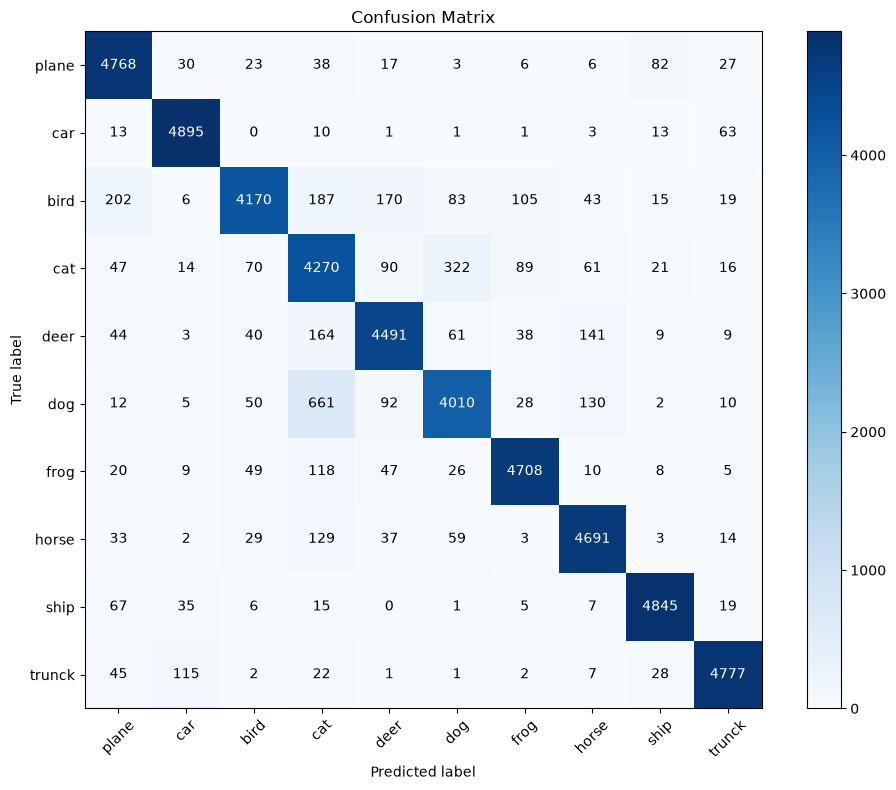

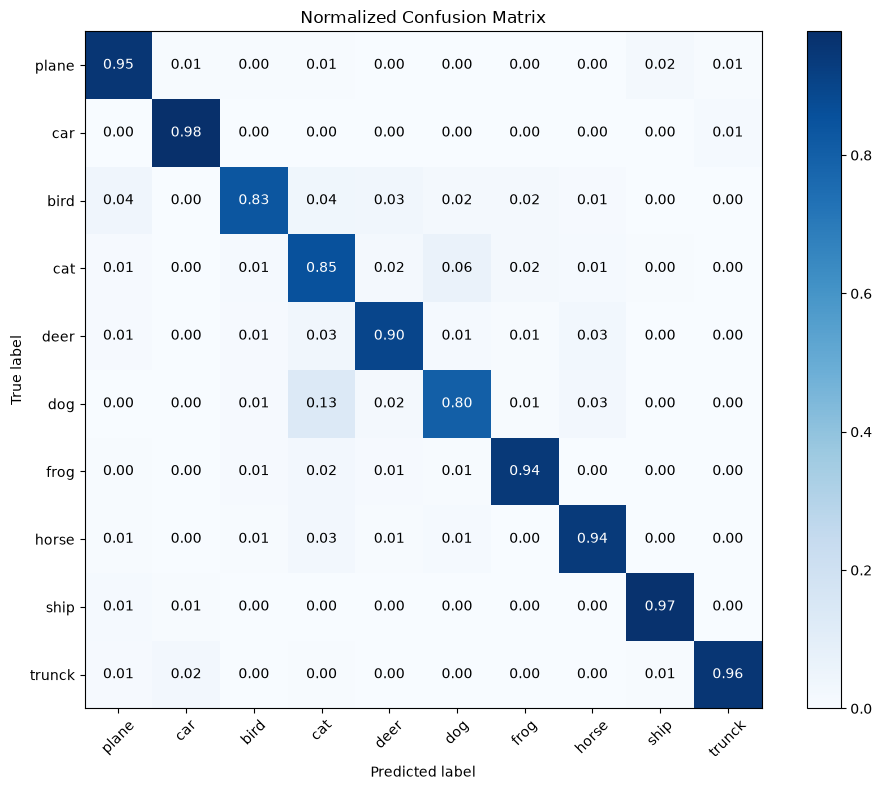

In [157]:
def plot_confusion_matrix(matrix, class_names, normalize = False):
    display_matrix = matrix.astype(float)

    if normalize:
        row_sums = display_matrix.sum(axis=1, keepdims=True)
        display_matrix = np.divide(
            display_matrix,
            row_sums,
            out=np.zeros_like(display_matrix),
            where=row_sums != 0,
        )

    plt.figure(figsize=(10, 8))
    plt.imshow(display_matrix, interpolation="nearest", cmap="Blues")
    plt.title("Normalized Confusion Matrix" if normalize else "Confusion Matrix")
    plt.colorbar()

    tick_positions = np.arange(len(class_names))
    plt.xticks(tick_positions, class_names, rotation=45)
    plt.yticks(tick_positions, class_names)

    threshold = display_matrix.max() / 2

    for row in range(display_matrix.shape[0]):
        for column in range(display_matrix.shape[1]):
            value = display_matrix[row, column]
            text = f"{value:.2f}" if normalize else f"{int(value)}"

            plt.text(
                column,
                row,
                text,
                ha="center",
                va="center",
                color="white" if value > threshold else "black",
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(confusion, class_names, normalize=False)
plot_confusion_matrix(confusion, class_names, normalize=True)

In [158]:
print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

       plane     0.9080    0.9536    0.9303      5000
         car     0.9572    0.9790    0.9680      5000
        bird     0.9394    0.8340    0.8836      5000
         cat     0.7606    0.8540    0.8046      5000
        deer     0.9080    0.8982    0.9031      5000
         dog     0.8780    0.8020    0.8383      5000
        frog     0.9444    0.9416    0.9430      5000
       horse     0.9200    0.9382    0.9290      5000
        ship     0.9640    0.9690    0.9665      5000
      trunck     0.9633    0.9554    0.9593      5000

    accuracy                         0.9125     50000
   macro avg     0.9143    0.9125    0.9126     50000
weighted avg     0.9143    0.9125    0.9126     50000

